# Audit Data — Marketplace Olist Brazilian E-Commerce

**Module :** Traitement de Données  
**Dataset :** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

---

Ce notebook analyse une marketplace e-commerce brésilienne. Il est structuré en cinq étapes :

- **Étape 1** : chargement et exploration des données brutes
- **Étape 2** : nettoyage et construction de la table finale
- **Étape 3** : construction des indicateurs et analyse globale
- **Étape 4** : analyses métier approfondies
- **Étape 5** : synthèse et recommandations

Le code est reproductible : il suffit de placer les fichiers CSV dans le même dossier que ce notebook.

# Étape 1 — Chargement et exploration des données

Cette étape a trois objectifs :

- Charger les fichiers CSV et vérifier leur intégrité (taille, types)
- Identifier les clés primaires et les liens entre les tables
- Repérer les premières anomalies : valeurs manquantes, statuts, doublons

## 1.1 — Imports des bibliothèques

Les quatre bibliothèques utilisées dans ce projet :

| Bibliothèque | Rôle |
|---|---|
| `pandas` | Charger et manipuler les données |
| `numpy` | Calculs numériques |
| `matplotlib` | Graphiques de base |
| `seaborn` | Graphiques plus esthétiques |

In [1]:
import pandas as pd              # pandas est la bibliothèque principale pour manipuler des tableaux de données (DataFrames)
import numpy as np               # numpy permet de faire des calculs numériques (moyennes, arrondis, etc.)
import matplotlib.pyplot as plt  # matplotlib permet de tracer des graphiques (courbes, barres, histogrammes, etc.)
import seaborn as sns            # seaborn est basé sur matplotlib, mais produit des graphiques plus esthétiques

pd.set_option('display.max_columns', 20)  # autorise l'affichage de jusqu'à 20 colonnes dans un DataFrame (par défaut : 10)
pd.set_option('display.width', 120)       # fixe la largeur d'affichage à 120 caractères pour éviter les coupures de lignes

print('Bibliothèques importées avec succès.')  # message de confirmation que tout s'est bien chargé

Bibliothèques importées avec succès.


## 1.2 — Chargement des fichiers CSV

Le dataset Olist contient **9 fichiers CSV**. Chaque fichier correspond à une entité de la marketplace :

- commandes, clients, articles, produits, vendeurs
- paiements, avis clients, géolocalisation, traductions des catégories

Tous les fichiers sont chargés dès le début pour avoir une vue complète avant toute transformation.

In [2]:
path = ''  # laisser vide si les CSV sont dans le même dossier que le notebook
           # exemple : path = 'data/' si les fichiers sont dans un sous-dossier 'data'

orders       = pd.read_csv(path + 'olist_orders_dataset.csv')
customers    = pd.read_csv(path + 'olist_customers_dataset.csv')
items        = pd.read_csv(path + 'olist_order_items_dataset.csv')
products     = pd.read_csv(path + 'olist_products_dataset.csv')
sellers      = pd.read_csv(path + 'olist_sellers_dataset.csv')
payments     = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews      = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
geolocation  = pd.read_csv(path + 'olist_geolocation_dataset.csv')
translations = pd.read_csv(path + 'product_category_name_translation.csv')

print('Les 9 fichiers ont été chargés avec succès.')

Les 9 fichiers ont été chargés avec succès.


## 1.3 — Tableau récapitulatif des tables

Ce tableau donne une vue rapide de chaque table : nombre de lignes, colonnes et liste des colonnes.

> **Observations importantes :**
> - `payments` a plus de lignes que `orders` → une commande peut avoir plusieurs paiements
> - `items` aussi → une commande peut contenir plusieurs articles
> - Ces deux tables devront être **agrégées** avant toute jointure

In [3]:
# On regroupe toutes les tables dans un dictionnaire
# clé = nom de la table (str), valeur = le DataFrame correspondant
# Cela permet de les parcourir avec une seule boucle au lieu de répéter le code 9 fois
tables = {
    'orders':       orders,
    'customers':    customers,
    'items':        items,
    'products':     products,
    'sellers':      sellers,
    'payments':     payments,
    'reviews':      reviews,
    'geolocation':  geolocation,
    'translations': translations,
}

recap_rows = []  # liste vide — elle va recevoir un dictionnaire par table à chaque itération de la boucle

for name, df in tables.items():  # .items() retourne des paires (clé, valeur) — ici (nom_table, DataFrame)
    recap_rows.append({          # .append() ajoute un élément à la fin de la liste
        'Table':            name,                           # nom de la table (ex: 'orders')
        'Lignes':           df.shape[0],                    # df.shape retourne un tuple (nb_lignes, nb_colonnes) — [0] = lignes
        'Colonnes':         df.shape[1],                    # [1] = nombre de colonnes
        'Colonnes (liste)': list(df.columns)  # df.columns = Index des noms de colonnes
                                                            # .tolist() convertit l'Index en liste Python ordinaire
                                                            # ', '.join() colle les éléments de la liste avec une virgule
    })

recap = pd.DataFrame(recap_rows)  # pd.DataFrame() transforme la liste de dictionnaires en un seul DataFrame
                                   # chaque dictionnaire de la liste devient une ligne du tableau final
display(recap)                     # display() affiche le DataFrame avec un rendu HTML propre dans Jupyter
                                   # (plus lisible que print() pour les tableaux)

,Table,Lignes,Colonnes,Colonnes (liste)
0,orders,99441,8,"[order_id, customer_id, order_status, order_pu..."
1,customers,99441,5,"[customer_id, customer_unique_id, customer_zip..."
2,items,112650,7,"[order_id, order_item_id, product_id, seller_i..."
3,products,32951,9,"[product_id, product_category_name, product_na..."
4,sellers,3095,4,"[seller_id, seller_zip_code_prefix, seller_cit..."
5,payments,103886,5,"[order_id, payment_sequential, payment_type, p..."
6,reviews,99224,7,"[review_id, order_id, review_score, review_com..."
7,geolocation,1000163,5,"[geolocation_zip_code_prefix, geolocation_lat,..."
8,translations,71,2,"[product_category_name, product_category_name_..."


## 1.4 — Exploration détaillée de chaque table

Pour chaque table, on affiche :

- `.info()` → types des colonnes et valeurs manquantes
- `.head(3)` et `.tail(3)` → aperçu des valeurs
- `.describe()` → statistiques des colonnes numériques (min, max, moyenne)

> **Objectif :** repérer les anomalies évidentes avant de nettoyer.

In [4]:
for name, df in tables.items():
    print('=' * 65)
    print(f'  TABLE : {name.upper()}')
    print(f'  {df.shape[0]:,} lignes  |  {df.shape[1]} colonnes')
    print('=' * 65)

    print('\n--- Types et valeurs manquantes ---')
    df.info()

    print('\n--- Aperçu des premières lignes ---')
    display(df.head(3))

    print('\n--- Aperçu des dernières lignes  ---')
    display(df.tail(3))

    num_cols = df.select_dtypes(include='number').columns.tolist()
    if num_cols:
        print(f'\n--- Statistiques descriptives des colonnes numériques (.describe) ---')
        display(df[num_cols].describe().round(2))

    print('\n')

  TABLE : ORDERS
  99,441 lignes  |  8 colonnes

--- Types et valeurs manquantes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

--- Aperçu des premières lignes ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



--- Aperçu des dernières lignes  ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00




  TABLE : CUSTOMERS
  99,441 lignes  |  5 colonnes

--- Types et valeurs manquantes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

--- Aperçu des premières lignes ---


...

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1000163.00,1000163.00,1000163.00
mean,36574.17,-21.18,-46.39
std,30549.34,5.72,4.27
min,1001.00,-36.61,-101.47
25%,11075.00,-23.60,-48.57
50%,26530.00,-22.92,-46.64
75%,63504.00,-19.98,-43.77
max,99990.00,45.07,121.11




  TABLE : TRANSLATIONS
  71 lignes  |  2 colonnes

--- Types et valeurs manquantes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB

--- Aperçu des premières lignes ---


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto



--- Aperçu des dernières lignes  ---


,product_category_name,product_category_name_english
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes
70,seguros_e_servicos,security_and_services


## 1.5 — Vérification des clés primaires

Une **clé primaire** est une colonne dont toutes les valeurs sont uniques dans la table.

**Méthode de vérification :** on compare le nombre de valeurs uniques au nombre total de lignes.
- Si égaux → clé valide
- Si différents → doublons ou clé composite

> **Pourquoi c'est important ?** Une jointure sur une colonne non unique multiplie les lignes et fausse les calculs.

In [5]:
# Dictionnaire : nom de table -> colonne supposée être la clé primaire
primary_keys = {
    'orders'      : 'order_id',
    'customers'   : 'customer_id',
    'items'       : None,           # clé composite : (order_id, order_item_id)
    'products'    : 'product_id',
    'sellers'     : 'seller_id',
    'payments'    : None,           # plusieurs lignes par order_id (multi-paiements)
    'reviews'     : 'review_id',
    'geolocation' : None,           # plusieurs coordonnées par code postal
    'translations': 'product_category_name',
}

print(f'{"Table":<15} {"Clé primaire":<30} {"Unique":<10} {"Total lignes":<15} {"Valide ?"}')
print('-' * 80)

for name, df in tables.items():
    col = primary_keys[name]
    if col is None:
        print(f'{name:<15} {"(pas de clé simple)":<30} {"—":<10} {df.shape[0]:<15} —')
    else:
        n_unique = df[col].nunique()
        n_total  = df.shape[0]
        valide   = 'OUI' if n_unique == n_total else f'NON ({n_unique} uniques pour {n_total} lignes)'
        print(f'{name:<15} {col:<30} {n_unique:<10} {n_total:<15} {valide}')

Table           Clé primaire                   Unique     Total lignes    Valide ?
--------------------------------------------------------------------------------
orders          order_id                       99441      99441           OUI
customers       customer_id                    99441      99441           OUI
items           (pas de clé simple)            —          112650          —
products        product_id                     32951      32951           OUI
sellers         seller_id                      3095       3095            OUI
payments        (pas de clé simple)            —          103886          —
reviews         review_id                      98410      99224           NON (98410 uniques pour 99224 lignes)
geolocation     (pas de clé simple)            —          1000163         —
translations    product_category_name          71         71              OUI


## 1.6 — Observations sur les colonnes clés

On compte les valeurs des colonnes catégorielles les plus importantes :

- **Statuts de commande** (`orders`) → détermine le périmètre de l'analyse
- **Types de paiement** (`payments`) → permet d'anticiper les problèmes d'agrégation
- **Notes clients** (`reviews`) → première indication sur la satisfaction

In [6]:
print('--- Distribution des statuts de commande (orders) ---')
print(orders['order_status'].value_counts())
print()

print('--- Distribution des types de paiement (payments) ---')
print(payments['payment_type'].value_counts())
print()

print('--- Distribution des notes clients (reviews) ---')
print(reviews['review_score'].value_counts().sort_index())
print()

print('--- Valeurs manquantes dans reviews (commentaires) ---')
print(reviews[['review_comment_title', 'review_comment_message']].isnull().sum())
print()

print('--- Nombre de commandes avec plusieurs articles (items) ---')
multi = items.groupby('order_id')['order_item_id'].max()
print(multi.value_counts().head(5))
print()

print('--- Nombre de lignes de paiement par commande (payments) ---')
multi_pay = payments.groupby('order_id')['payment_sequential'].max()
print(multi_pay.value_counts().head(5))

--- Distribution des statuts de commande (orders) ---
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

--- Distribution des types de paiement (payments) ---
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

--- Distribution des notes clients (reviews) ---
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

--- Valeurs manquantes dans reviews (commentaires) ---


review_comment_title      87656
review_comment_message    58247
dtype: int64

--- Nombre de commandes avec plusieurs articles (items) ---
order_item_id
1    88863
2     7516
3     1322
4      505
5      204
Name: count, dtype: int64

--- Nombre de lignes de paiement par commande (payments) ---
payment_sequential
1    96401
2     2458
3      303
4      108
5       52
Name: count, dtype: int64


## 1.7 — Signification des colonnes principales

### `orders` — Commandes

| Colonne | Description |
|---|---|
| `order_id` | Identifiant unique de la commande |
| `customer_id` | Lien vers la table customers |
| `order_status` | Statut : delivered, shipped, canceled… |
| `order_purchase_timestamp` | Date et heure d'achat |
| `order_delivered_customer_date` | Date réelle de livraison |
| `order_estimated_delivery_date` | Date estimée (utilisée pour calculer les retards) |

---

### `customers` — Clients

| Colonne | Description |
|---|---|
| `customer_id` | Clé de jointure avec orders |
| `customer_unique_id` | Vrai identifiant du client (un client peut avoir plusieurs customer_id) |
| `customer_state` | État brésilien du client |
| `customer_zip_code_prefix` | Code postal |

---

### `items` — Articles commandés

| Colonne | Description |
|---|---|
| `order_id` | Lien vers la commande |
| `order_item_id` | Numéro de l'article dans la commande |
| `product_id` | Lien vers le produit |
| `seller_id` | Lien vers le vendeur |
| `price` | Prix de l'article |
| `freight_value` | Frais de livraison |

---

### `products` — Produits

| Colonne | Description |
|---|---|
| `product_id` | Identifiant unique |
| `product_category_name` | Catégorie en portugais |
| `product_weight_g` | Poids en grammes |
| `product_length_cm` / `height` / `width` | Dimensions |

---

### `sellers` — Vendeurs

| Colonne | Description |
|---|---|
| `seller_id` | Identifiant unique |
| `seller_state` | État du vendeur |
| `seller_zip_code_prefix` | Code postal |

---

### `payments` — Paiements

| Colonne | Description |
|---|---|
| `order_id` | Lien vers la commande |
| `payment_sequential` | Numéro du paiement (1 = premier) |
| `payment_type` | Moyen de paiement : credit_card, boleto… |
| `payment_installments` | Nombre de versements |
| `payment_value` | Montant encaissé |

---

### `reviews` — Avis clients

| Colonne | Description |
|---|---|
| `review_id` | Identifiant unique |
| `order_id` | Lien vers la commande |
| `review_score` | Note de 1 à 5 |
| `review_comment_message` | Commentaire (souvent vide) |

---

### `geolocation` — Géolocalisation

| Colonne | Description |
|---|---|
| `geolocation_zip_code_prefix` | Code postal |
| `geolocation_lat` / `lng` | Coordonnées GPS |
| `geolocation_state` | État brésilien |

---

### `translations` — Traductions

| Colonne | Description |
|---|---|
| `product_category_name` | Catégorie en portugais |
| `product_category_name_english` | Traduction en anglais |

## 1.8 — Schéma des relations entre les tables

`orders` est la table centrale. Presque toutes les autres tables se connectent à elle via `order_id`.

**Deux tables sans lien formel :**
- `geolocation` → jointure possible via `zip_code_prefix`, mais nécessite une agrégation préalable
- `translations` → jointure via `product_category_name` (relation logique, pas de clé étrangère déclarée)

> `items` a une **clé primaire composite** : `order_id + order_item_id`

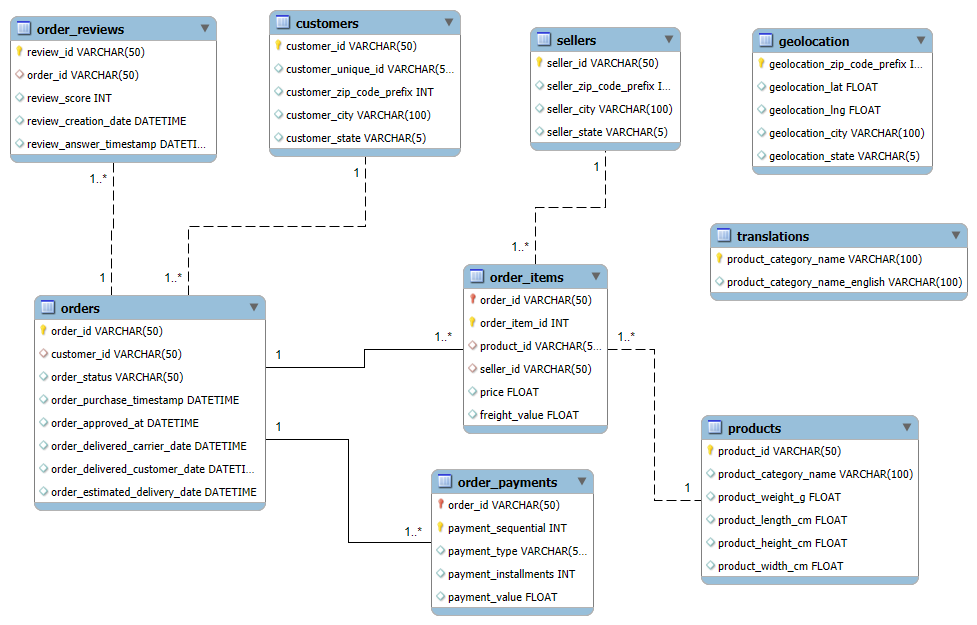

In [7]:
from IPython.display import Image, display  # Image = classe pour charger une image depuis le disque
                                            # display = force l'affichage dans la cellule Jupyter

# Image(filename=...) charge l'image depuis le fichier PNG
# Le fichier schema_relations.png doit être dans le même dossier que ce notebook
display(Image(filename='schema_relations.png'))

### Conclusion — 1.8

La table `orders` est la table centrale du dataset.  
Presque toutes les autres tables se connectent à elle via `order_id`.

Deux tables n'ont pas de lien formel dans le schéma :
- **`geolocation`** : peut être jointe via `zip_code_prefix` (customers ou sellers), mais il faut d'abord l'agréger.
- **`translations`** : jointe via `product_category_name` (products), relation logique mais sans FK déclarée.

La table `items` a une **clé primaire composite** : `order_id + order_item_id`.  
Cela signifie qu'une même commande peut avoir plusieurs lignes dans cette table.

## 1.9 — Tables retenues pour l'analyse

| Table | Décision | Raison |
|---|---|---|
| `orders` | Retenue | Table centrale, contient tous les statuts et dates |
| `customers` | Retenue | Localisation géographique des clients |
| `items` | Retenue | Prix et frais de livraison par article |
| `products` | Retenue | Catégories, poids et dimensions |
| `sellers` | Retenue | Localisation des vendeurs |
| `payments` | Retenue | Montants réels et modes de paiement |
| `reviews` | Retenue | Note et satisfaction client |
| `translations` | Retenue | Traduction des catégories (graphiques lisibles) |
| `geolocation` | Optionnelle | Coordonnées GPS — utilisée si le temps le permet |

## Synthèse — Étape 1

| Tâche | Statut |
|---|---|
| Chargement des 9 fichiers CSV | ✅ |
| Tableau récapitulatif | ✅ |
| Exploration avec .info() et .describe() | ✅ |
| Vérification des clés primaires | ✅ |
| Observations sur les colonnes catégorielles | ✅ |
| Schéma des relations | ✅ |
| Justification des tables retenues | ✅ |

**Points importants pour l'étape 2 :**

- Les colonnes de dates sont de type `object` → à convertir en `datetime`
- `payments` et `items` ont plusieurs lignes par commande → à agréger avant jointure
- `geolocation` a beaucoup de doublons par code postal → à agréger par médiane
- `review_comment_title` et `review_comment_message` sont souvent vides → comportement normal
- **96 478 commandes** ont le statut `delivered` → périmètre principal de l'analyse

# Étape 2 — Nettoyage et construction de la table finale

Le nettoyage est l'étape la plus importante. Une erreur ici se propage dans toute l'analyse sans message d'erreur.

Cette étape est divisée en trois phases :

- **Phase A** : nettoyage table par table
- **Phase B** : réponses aux trois questions difficiles
- **Phase C** : agrégations, jointures et construction de la table finale

## Phase A — Nettoyage table par table

Pour chaque table, on applique la même routine dans cet ordre :

1. Copie de travail (les données brutes restent intactes)
2. Suppression des doublons sur la clé primaire
3. Conversion des dates en `datetime`
4. Normalisation des textes (minuscules, suppression des espaces)
5. Vérification des colonnes numériques (valeurs négatives ou nulles)
6. Traitement des valeurs manquantes avec justification
7. Affichage du nombre de lignes avant et après

### 2.1 — Nettoyage de `orders`

`orders` est la table centrale. Son nettoyage conditionne toute l'analyse.

**Points à traiter :**
- 5 colonnes de dates chargées comme `object` → à convertir en `datetime`
- `order_approved_at` peut être vide → normal, la commande n'est pas encore approuvée
- Incohérences chronologiques à supprimer (livraison avant achat)

In [9]:
df_orders = orders.copy()  # copie de travail — les données brutes restent intactes dans `orders`

print(f'orders avant nettoyage : {orders.shape}')

# -- Doublons sur la clé primaire --
n_dup = df_orders.duplicated(subset='order_id').sum()
print(f'Doublons sur order_id : {n_dup}')
df_orders = df_orders.drop_duplicates(subset='order_id')

# -- Conversion des dates --
date_cols_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols_orders:
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')

# -- AJOUT : Détection et suppression des incohérences de dates --
# Anomalie 1 : La livraison client a eu lieu AVANT l'achat
incoh_livraison = df_orders['order_delivered_customer_date'] < df_orders['order_purchase_timestamp']

# Anomalie 2 : La remise au transporteur a eu lieu AVANT l'achat
incoh_transport = df_orders['order_delivered_carrier_date'] < df_orders['order_purchase_timestamp']

# Cumul des incohérences temporelles
incoherences_totatles = incoh_livraison | incoh_transport
n_incoh = incoherences_totatles.sum()

print(f'Incohérences chronologiques détectées (Livraison/Transport < Achat) : {n_incoh}')

if n_incoh > 0:
    # On ne garde que les lignes qui n'ont PAS d'incohérence (le symbole ~ signifie "NOT")
    df_orders = df_orders[~incoherences_totatles]

# -- Textes --
df_orders['order_status'] = df_orders['order_status'].str.strip().str.lower()

# -- Numériques --
# orders ne contient pas de colonnes numériques à vérifier

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_orders :')
print(df_orders.isnull().sum()[df_orders.isnull().sum() > 0])

print(f'\norders après nettoyage  : {df_orders.shape}')
display(df_orders.head(3))

orders avant nettoyage : (99441, 8)
Doublons sur order_id : 0
Incohérences chronologiques détectées (Livraison/Transport < Achat) : 166

Valeurs manquantes dans df_orders :
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2964
dtype: int64

orders après nettoyage  : (99275, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


### 2.2 — Nettoyage de `customers`

Table simple : pas de dates, pas de numériques sensibles.

**Points à traiter :**
- `customer_city` et `customer_state` → normaliser la casse pour éviter les doublons textuels
- `customer_zip_code_prefix` → convertir en texte (pas un nombre)

> `customer_id` ≠ `customer_unique_id` : un même client peut passer plusieurs commandes avec des `customer_id` différents.

In [10]:
df_customers = customers.copy()

print(f'customers avant nettoyage : {customers.shape}')

# -- Doublons --
n_dup = df_customers.duplicated(subset='customer_id').sum()
print(f'Doublons sur customer_id : {n_dup}')
df_customers = df_customers.drop_duplicates(subset='customer_id')

# -- Dates -- aucune colonne de date dans cette table

# -- Textes --
df_customers['customer_city']  = df_customers['customer_city'].str.strip().str.lower()
df_customers['customer_state'] = df_customers['customer_state'].str.strip().str.upper()
# .str.upper() pour customer_state : les codes d'état brésiliens sont des sigles en majuscules (SP, RJ, MG...)

# -- Numériques --
# customer_zip_code_prefix est un code postal — il ne doit pas être traité comme un nombre
# On le convertit en chaîne de caractères pour éviter toute opération arithmétique accidentelle
df_customers['customer_zip_code_prefix'] = df_customers['customer_zip_code_prefix'].astype(str).str.zfill(5)
# .zfill(5) remet les zéros en tête si le code postal a moins de 5 chiffres (ex: '603' -> '00603')

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_customers :')
na = df_customers.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')

print(f'\ncustomers après nettoyage : {df_customers.shape}')

customers avant nettoyage : (99441, 5)
Doublons sur customer_id : 0

Valeurs manquantes dans df_customers :
Aucune valeur manquante.

customers après nettoyage : (99441, 5)


### 2.3 — Nettoyage de `items`

`items` est la source principale pour calculer le chiffre d'affaires.

**Points à traiter :**
- Clé primaire composite : `(order_id, order_item_id)`
- `price` et `freight_value` → vérifier les valeurs négatives ou nulles

> Cette table ne peut pas être jointe directement à `orders` sans agrégation préalable.

In [25]:
df_items = items.copy()

print(f'items avant nettoyage : {items.shape}')

# -- Doublons --
# La clé primaire de items est composite : (order_id, order_item_id)
# Un doublon réel serait la même commande avec le même numéro d'article deux fois
n_dup = df_items.duplicated(subset=['order_id', 'order_item_id']).sum()
print(f'Doublons sur (order_id, order_item_id) : {n_dup}')
df_items = df_items.drop_duplicates(subset=['order_id', 'order_item_id'])

# -- Dates --
df_items['shipping_limit_date'] = pd.to_datetime(df_items['shipping_limit_date'], errors='coerce')

# -- Textes -- aucune colonne textuelle métier dans cette table

# -- Numériques --
print(f'\nPrix négatifs ou nuls (price <= 0)       : {(df_items["price"] <= 0).sum()}')
print(f'Frais négatifs ou nuls (freight <= 0)    : {(df_items["freight_value"] <= 0).sum()}')
# Les frais de livraison peuvent légitimement être à 0 (livraison offerte)
# On conserve ces lignes mais on les signale

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_items :')
na = df_items.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')

print(f'\nitems après nettoyage : {df_items.shape}')
display(df_items)

items avant nettoyage : (112650, 7)
Doublons sur (order_id, order_item_id) : 0

Prix négatifs ou nuls (price <= 0)       : 0
Frais négatifs ou nuls (freight <= 0)    : 383

Valeurs manquantes dans df_items :
Aucune valeur manquante.

items après nettoyage : (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


### 2.4 — Nettoyage de `products`

**Points à traiter :**
- `product_category_name` vide → remplacée par `'desconhecido'` pour conserver le produit dans l'analyse
- Dimensions négatives → supprimées
- Dimensions nulles → conservées (vérification supplémentaire nécessaire)

> Les colonnes `product_name_lenght` et `product_description_lenght` contiennent une faute de frappe dans le dataset original (`lenght` au lieu de `length`). Non corrigée pour rester fidèle à la source.

In [26]:
df_products = products.copy()

print(f'products avant nettoyage : {products.shape}')

# -- Doublons --
n_dup = df_products.duplicated(subset='product_id').sum()
print(f'Doublons sur product_id : {n_dup}')
df_products = df_products.drop_duplicates(subset='product_id')

# -- Dates -- aucune colonne de date dans cette table

# -- Textes --
df_products['product_category_name'] = (
    df_products['product_category_name']
    .str.strip()
    .str.lower()
    .fillna('desconhecido')  # remplace les NaN par 'desconhecido' pour conserver ces produits dans les analyses de volume
)

# -- Numériques --
dims = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in dims:
    n_neg = (df_products[col] < 0).sum()
    if n_neg > 0:
        print(f'Valeurs négatives dans {col} : {n_neg} -> supprimées')
        df_products = df_products[df_products[col] >= 0]
    # Les valeurs nulles (0) sont théoriquement impossibles pour des dimensions physiques
    # mais on les conserve plutôt que de les supprimer sans vérification supplémentaire

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_products après remplacement de la catégorie :')
na = df_products.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')
# Les NaN restants sur les dimensions sont conservés intentionnellement

print(f'\nproducts après nettoyage : {df_products.shape}')
display(df_products)

products avant nettoyage : (32951, 9)
Doublons sur product_id : 0

Valeurs manquantes dans df_products après remplacement de la catégorie :
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

products après nettoyage : (32951, 9)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


### 2.5 — Nettoyage de `sellers`

Structure identique à `customers`. Même traitement appliqué.

**Points à traiter :**
- `seller_city` et `seller_state` → normaliser la casse
- `seller_zip_code_prefix` → convertir en texte

In [27]:
df_sellers = sellers.copy()

print(f'sellers avant nettoyage : {sellers.shape}')

# -- Doublons --
n_dup = df_sellers.duplicated(subset='seller_id').sum()
print(f'Doublons sur seller_id : {n_dup}')
df_sellers = df_sellers.drop_duplicates(subset='seller_id')

# -- Textes --
df_sellers['seller_city']  = df_sellers['seller_city'].str.strip().str.lower()
df_sellers['seller_state'] = df_sellers['seller_state'].str.strip().str.upper()

# -- Numériques --
df_sellers['seller_zip_code_prefix'] = df_sellers['seller_zip_code_prefix'].astype(str).str.zfill(5)

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_sellers :')
na = df_sellers.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')

print(f'\nsellers après nettoyage : {df_sellers.shape}')
display(df_sellers)

sellers avant nettoyage : (3095, 4)
Doublons sur seller_id : 0

Valeurs manquantes dans df_sellers :
Aucune valeur manquante.

sellers après nettoyage : (3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,04195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,04650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


### 2.6 — Nettoyage de `payments`

Une commande peut avoir plusieurs lignes de paiement (ex : carte + bon de réduction).

**Points à traiter :**
- Clé primaire composite : `(order_id, payment_sequential)`
- `payment_value` négative → supprimée
- `payment_type = 'not_defined'` → conservée (le montant reste valide)

In [28]:
df_payments = payments.copy()

print(f'payments avant nettoyage : {payments.shape}')

# -- Doublons --
# La clé primaire est composite : (order_id, payment_sequential)
n_dup = df_payments.duplicated(subset=['order_id', 'payment_sequential']).sum()
print(f'Doublons sur (order_id, payment_sequential) : {n_dup}')
df_payments = df_payments.drop_duplicates(subset=['order_id', 'payment_sequential'])

# -- Textes --
df_payments['payment_type'] = df_payments['payment_type'].str.strip().str.lower()

# -- Numériques --
print(f'\nValeurs négatives dans payment_value : {(df_payments["payment_value"] < 0).sum()}')
df_payments = df_payments[df_payments['payment_value'] >= 0]
# On supprime les valeurs négatives car elles sont incohérentes avec la réalité d'un paiement

print(f'Lignes avec payment_type = not_defined : {(df_payments["payment_type"] == "not_defined").sum()}')
# Conservées : le montant est valide, seul le mode de paiement est inconnu

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_payments :')
na = df_payments.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')

print(f'\npayments après nettoyage : {df_payments.shape}')
display(df_payments)

payments avant nettoyage : (103886, 5)
Doublons sur (order_id, payment_sequential) : 0

Valeurs négatives dans payment_value : 0
Lignes avec payment_type = not_defined : 3

Valeurs manquantes dans df_payments :
Aucune valeur manquante.

payments après nettoyage : (103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


### 2.7 — Nettoyage de `reviews`

**Points à traiter :**
- `review_score` doit être entre 1 et 5 → valeurs hors intervalle supprimées
- Plusieurs avis par commande → on garde uniquement le plus récent (`review_answer_timestamp`)
- `review_comment_title` et `review_comment_message` souvent vides → comportement normal, conservés

In [29]:
df_reviews = reviews.copy()

print(f'reviews avant nettoyage : {reviews.shape}')

# -- Doublons sur review_id --
n_dup = df_reviews.duplicated(subset='review_id').sum()
print(f'Doublons sur review_id : {n_dup}')
df_reviews = df_reviews.drop_duplicates(subset='review_id')

# -- Dates --
df_reviews['review_creation_date']    = pd.to_datetime(df_reviews['review_creation_date'],    errors='coerce')
df_reviews['review_answer_timestamp'] = pd.to_datetime(df_reviews['review_answer_timestamp'], errors='coerce')

# -- Numériques : review_score doit être dans [1, 5] --
hors_intervalle = df_reviews[~df_reviews['review_score'].between(1, 5)].shape[0]
print(f'Notes hors intervalle [1, 5] : {hors_intervalle} -> supprimées')
df_reviews = df_reviews[df_reviews['review_score'].between(1, 5)]

# -- Plusieurs avis par commande : on garde le plus récent --
n_avant = df_reviews.shape[0]
df_reviews = (
    df_reviews
    .sort_values('review_answer_timestamp', ascending=False)
    .drop_duplicates(subset='order_id', keep='first')
    # keep='first' conserve la ligne avec la date la plus récente après le tri décroissant
)
print(f'Lignes supprimées (avis multiples par commande) : {n_avant - df_reviews.shape[0]}')

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_reviews :')
na = df_reviews.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')
# review_comment_title et review_comment_message sont vides pour la majorité des lignes
# Ce comportement est normal et documenté dans la description du dataset

print(f'\nreviews après nettoyage : {df_reviews.shape}')
display(df_reviews)

reviews avant nettoyage : (99224, 7)
Doublons sur review_id : 814
Notes hors intervalle [1, 5] : 0 -> supprimées
Lignes supprimées (avis multiples par commande) : 243

Valeurs manquantes dans df_reviews :
review_comment_title      86654
review_comment_message    57592
dtype: int64

reviews après nettoyage : (98167, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
80582,13548d0f62b03a0d3cb6efc00877fa13,30a2f24dd6770c91faa6b3481319204b,5,NaN,NaN,2018-08-14 00:00:00,2018-10-29 12:27:35
49615,728d5cfdc7283cfd0a8061d7581a19f8,7e8072dc0f35ebb0c1b2a4743e0f179a,5,NaN,NaN,2018-07-12 00:00:00,2018-10-26 21:36:41
92802,6c883909cf53725a13caf477a70f00a4,7ce4e38f4eadd993bb5b2e60bb7f7bec,5,Muito bonita,"Amei a mesinha, que pena que me confundir na c...",2018-08-16 00:00:00,2018-10-24 21:34:38
14687,abf08328d2f1f0e8a33eee9f52f502f6,99e4a1f9377bf28f08f54a2eecccbf0d,5,NaN,NaN,2018-02-02 00:00:00,2018-10-24 18:26:25
46904,6c50d16eb583d5db7e841b77e89b7045,0b223d92c27432930dfe407c6aea3041,5,NaN,NaN,2018-08-31 00:00:00,2018-10-24 16:27:36
...,...,...,...,...,...,...,...
41042,b2d5d8db2a841d27a72e4c06c6212368,9aa3197e4887919fde0307fc23601d7a,4,NaN,Só chegou uma parte do pedido ate agora..,2016-10-15 00:00:00,2016-10-17 21:02:49
28075,53752edb26544dd41c1209f582c9c589,b8b9d7046c083150cb5360b83a8ebb51,5,NaN,O pedido foi entregue antes do prazo pr0metido,2016-10-16 01:00:00,2016-10-16 15:45:11
60439,743d98b1a4782f0646898fc915ef002a,e2144124f98f3bf46939bc5183104041,4,NaN,NaN,2016-10-15 00:00:00,2016-10-16 03:20:17
5503,49f695dffa457eaba90d388a5c37e942,e5215415bb6f76fe3b7cb68103a0d1c0,1,NaN,"PRODUTO NÃO CHEGOU,E JÁ PASSOU O PRAZO DE ENTREGA",2016-10-09 00:00:00,2016-10-11 14:31:29


### 2.8 — Nettoyage de `translations`

Table de référence simple (71 lignes, 2 colonnes).

**Point critique :** les noms de catégories doivent être écrits exactement de la même façon dans `products` et `translations`, sinon la jointure produit des valeurs manquantes.

**Action :** normalisation stricte des deux colonnes (minuscules, suppression des espaces).

In [30]:
df_translations = translations.copy()

print(f'translations avant nettoyage : {translations.shape}')

# -- Doublons --
n_dup = df_translations.duplicated(subset='product_category_name').sum()
print(f'Doublons sur product_category_name : {n_dup}')
df_translations = df_translations.drop_duplicates(subset='product_category_name')

# -- Textes : normalisation stricte pour garantir la correspondance avec df_products --
df_translations['product_category_name']         = df_translations['product_category_name'].str.strip().str.lower()
df_translations['product_category_name_english'] = df_translations['product_category_name_english'].str.strip().str.lower()

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_translations :')
na = df_translations.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')

print(f'\ntranslations après nettoyage : {df_translations.shape}')
display(df_translations)

translations avant nettoyage : (71, 2)
Doublons sur product_category_name : 0

Valeurs manquantes dans df_translations :
Aucune valeur manquante.

translations après nettoyage : (71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


## Phase B — Trois questions difficiles

### 2.9 — Q1 : quelles valeurs manquantes supprimer, conserver ou remplacer ?

| Colonne | Décision | Justification |
|---|---|---|
| `order_delivered_customer_date` vide | Conserver | Commande non livrée — information utile |
| `order_approved_at` vide | Conserver | Commande non approuvée — cas rare |
| `review_comment_message` vide | Conserver | Client a noté sans commenter — normal |
| `review_score` vide | Supprimer | Sans note, la ligne est inutilisable |
| `product_category_name` vide | Remplacer par `'desconhecido'` | On garde le produit dans l'analyse |
| `product_weight_g` vide | Conserver | Utile pour la logistique, pas critique pour le CA |
| Incohérences de dates | Supprimer | Dates impossibles → calculs de délais faussés |

### 2.10 — Q2 : faut-il inclure les commandes annulées ?

**Non.** La table finale est construite uniquement à partir des commandes `delivered`.

**Raisons :**
- Une commande annulée n'a pas de date de livraison → impossible de calculer un délai
- Elle n'a généralement pas donné lieu à un paiement effectif
- L'inclure dans le CA ou la satisfaction introduirait des biais

> Le statut `delivered` représente **96 478 commandes sur 99 441**, soit environ 97 % du dataset.

### 2.11 — Q3 : quelles incohérences peuvent fausser les conclusions ?

Trois types d'incohérences identifiés :

| Incohérence | Impact | Traitement |
|---|---|---|
| Date de livraison < date d'achat | Délais faussés | Suppression en phase C |
| `items` et `payments` multi-lignes par commande | CA multiplié artificiellement | Agrégation avant jointure |
| `review_score` hors [1, 5] | Moyenne de satisfaction faussée | Suppression en phase A |

---
## Phase C — Agrégations, jointures et construction de la table finale

La table finale est construite en plusieurs étapes successives.
On commence par agréger les tables qui ont plusieurs lignes par commande,
puis on réalise les jointures dans un ordre logique en partant de `orders`.

Le nombre de lignes est affiché avant et après chaque jointure.
Une augmentation inattendue du nombre de lignes signale un problème
dans la clé de jointure utilisée et doit être investiguée immédiatement.

### 2.12 — Agrégation de `items`

On regroupe `df_items` par `order_id` pour obtenir une ligne par commande.

**Colonnes calculées :**
- `chiffre_affaires` : somme des prix
- `frais_livraison_total` : somme des frais
- `nb_articles` : nombre d'articles
- `seller_id` et `product_id` : récupérés depuis le premier article (`order_item_id == 1`)

In [ ]:
# Agrégation financière par commande
items_agg = df_items.groupby('order_id').agg(
    chiffre_affaires      = ('price',         'sum'),   # somme des prix de tous les articles
    frais_livraison_total = ('freight_value', 'sum'),   # somme des frais de livraison
    nb_articles           = ('order_item_id', 'max'),   # order_item_id max = nombre d'articles
).reset_index()

# Récupération du seller_id et du product_id principaux (premier article)
items_principal = (
    df_items[df_items['order_item_id'] == 1][['order_id', 'seller_id', 'product_id']]
)

items_agg = items_agg.merge(items_principal, on='order_id', how='left')

print(f'items agrégé : {items_agg.shape}')
print(f'Nombre de order_id uniques dans df_items : {df_items["order_id"].nunique()}')
# Ces deux nombres doivent être égaux

items agrégé : (98666, 6)
Nombre de order_id uniques dans df_items : 98666


### 2.13 — Agrégation de `payments`

On regroupe `df_payments` par `order_id` pour obtenir une ligne par commande.

**Colonnes calculées :**
- `montant_total_paye` : somme des montants
- `nb_paiements` : nombre de lignes de paiement
- `mode_paiement_principal` : type du premier paiement (`payment_sequential == 1`)

In [ ]:
# Agrégation financière par commande
payments_agg = df_payments.groupby('order_id').agg(
    montant_total_paye = ('payment_value',        'sum'),
    nb_paiements       = ('payment_sequential',   'max'),
).reset_index()

# Mode de paiement principal : le premier enregistrement (payment_sequential == 1)
payments_principal = (
    df_payments[df_payments['payment_sequential'] == 1][['order_id', 'payment_type']]
    .rename(columns={'payment_type': 'mode_paiement_principal'})
)

payments_agg = payments_agg.merge(payments_principal, on='order_id', how='left')

print(f'payments agrégé : {payments_agg.shape}')
print(f'Nombre de order_id uniques dans df_payments : {df_payments["order_id"].nunique()}')

payments agrégé : (99440, 4)
Nombre de order_id uniques dans df_payments : 99440


### 2.14 — Enrichissement de `products` avec les traductions

On ajoute les noms de catégories en anglais via une jointure avec `df_translations`.

- Jointure `left` → tous les produits sont conservés, même sans traduction
- Les produits sans traduction auront `product_category_name_english` = NaN

In [19]:
n_avant = df_products.shape[0]

df_products_enrichi = df_products.merge(
    df_translations[['product_category_name', 'product_category_name_english']],
    on='product_category_name',
    how='left',  # on conserve tous les produits, même sans traduction
)

print(f'products avant enrichissement : {n_avant}')
print(f'products après enrichissement : {df_products_enrichi.shape[0]}')
print(f'Catégories sans traduction    : {df_products_enrichi["product_category_name_english"].isnull().sum()}')

products avant enrichissement : 32951
products après enrichissement : 32951
Catégories sans traduction    : 623


### 2.15 — Construction de la table finale

**Point de départ :** commandes avec `order_status == 'delivered'`

**Jointures réalisées dans l'ordre :**

| Ordre | Table ajoutée | Clé de jointure |
|---|---|---|
| 1 | `customers` | `customer_id` |
| 2 | `items_agg` | `order_id` |
| 3 | `payments_agg` | `order_id` |
| 4 | `reviews` | `order_id` |
| 5 | `sellers` | `seller_id` |
| 6 | `products_enrichi` | `product_id` |

> Le nombre de lignes est vérifié après chaque jointure. Il doit rester identique à celui de la table de gauche.

In [ ]:
# -- Point de départ : commandes livrées uniquement --
df_final = df_orders[df_orders['order_status'] == 'delivered'].copy()
print(f'Départ (delivered uniquement)     : {df_final.shape[0]:>7,} lignes')

# -- Jointure 1 : informations clients --
df_final = df_final.merge(
    df_customers[['customer_id', 'customer_unique_id',
                  'customer_zip_code_prefix', 'customer_city', 'customer_state']],
    on='customer_id', how='left'
)
print(f'Après jointure customers          : {df_final.shape[0]:>7,} lignes')

# -- Jointure 2 : articles agrégés --
df_final = df_final.merge(items_agg, on='order_id', how='left')
print(f'Après jointure items_agg          : {df_final.shape[0]:>7,} lignes')

# -- Jointure 3 : paiements agrégés --
df_final = df_final.merge(payments_agg, on='order_id', how='left')
print(f'Après jointure payments_agg       : {df_final.shape[0]:>7,} lignes')

# -- Jointure 4 : avis clients --
df_final = df_final.merge(
    df_reviews[['order_id', 'review_score', 'review_id']],
    on='order_id', how='left'
)
print(f'Après jointure reviews            : {df_final.shape[0]:>7,} lignes')

# -- Jointure 5 : informations vendeurs --
df_final = df_final.merge(
    df_sellers[['seller_id', 'seller_city', 'seller_state', 'seller_zip_code_prefix']],
    on='seller_id', how='left'
)
print(f'Après jointure sellers            : {df_final.shape[0]:>7,} lignes')

# -- Jointure 6 : informations produits enrichies --
df_final = df_final.merge(
    df_products_enrichi[[
        'product_id', 'product_category_name_english',
        'product_weight_g', 'product_length_cm',
        'product_height_cm', 'product_width_cm'
    ]],
    on='product_id', how='left'
)
print(f'Après jointure products           : {df_final.shape[0]:>7,} lignes')

Départ (delivered uniquement)     :  96,313 lignes
Après jointure customers          :  96,313 lignes
Après jointure items_agg          :  96,313 lignes
Après jointure payments_agg       :  96,313 lignes
Après jointure reviews            :  96,313 lignes
Après jointure sellers            :  96,313 lignes
Après jointure products           :  96,313 lignes


### 2.16 — Suppression des incohérences de dates

Deux vérifications sur la table finale :

- Livraison réelle < date d'achat → supprimée
- Livraison réelle < date d'approbation → supprimée

In [21]:
n_avant = df_final.shape[0]

# Incohérence 1 : livraison avant achat
mask_1 = df_final['order_delivered_customer_date'] < df_final['order_purchase_timestamp']
print(f'Livraison avant achat     : {mask_1.sum()} lignes -> supprimées')

# Incohérence 2 : livraison avant approbation
mask_2 = df_final['order_delivered_customer_date'] < df_final['order_approved_at']
print(f'Livraison avant approbation : {mask_2.sum()} lignes -> supprimées')

df_final = df_final[~mask_1 & ~mask_2]

print(f'\nLignes supprimées pour incohérence de dates : {n_avant - df_final.shape[0]}')
print(f'Table finale après suppression des incohérences : {df_final.shape[0]:,} lignes')

Livraison avant achat     : 0 lignes -> supprimées
Livraison avant approbation : 61 lignes -> supprimées

Lignes supprimées pour incohérence de dates : 61
Table finale après suppression des incohérences : 96,252 lignes


### 2.17 — Vérification finale

On vérifie :
- Nombre de lignes et de colonnes
- Liste complète des colonnes disponibles
- Valeurs manquantes résiduelles

**Valeurs manquantes résiduelles attendues :**
- Commandes sans avis → `review_score` = NaN
- Produits sans traduction → `product_category_name_english` = NaN
- Commandes sans informations de transport → NaN sur certaines colonnes

> Ces NaN ne sont pas des erreurs. Chaque analyse exclura les lignes concernées uniquement sur les colonnes qu'elle utilise.

In [31]:
print('=' * 55)
print('  TABLE FINALE — df_final')
print('=' * 55)
print(f'  Lignes   : {df_final.shape[0]:,}')
print(f'  Colonnes : {df_final.shape[1]}')
print()
print('  Colonnes disponibles :')
for col in df_final.columns:
    print(f'    - {col}')
display (df_final)
print()
print('  Valeurs manquantes résiduelles :')
na_final = df_final.isnull().sum()
display(na_final[na_final > 0].to_frame('Manquants'))

  TABLE FINALE — df_final
  Lignes   : 96,252
  Colonnes : 30

  Colonnes disponibles :
    - order_id
    - customer_id
    - order_status
    - order_purchase_timestamp
    - order_approved_at
    - order_delivered_carrier_date
    - order_delivered_customer_date
    - order_estimated_delivery_date
    - customer_unique_id
    - customer_zip_code_prefix
    - customer_city
    - customer_state
    - chiffre_affaires
    - frais_livraison_total
    - nb_articles
    - seller_id
    - product_id
    - montant_total_paye
    - nb_paiements
    - mode_paiement_principal
    - review_score
    - review_id
    - seller_city
    - seller_state
    - seller_zip_code_prefix
    - product_category_name_english
    - product_weight_g
    - product_length_cm
    - product_height_cm
    - product_width_cm


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_score,review_id,seller_city,seller_state,seller_zip_code_prefix,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,03149,...,4.0,a54f0611adc9ed256b57ede6b6eb5114,maua,SP,09350,housewares,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,4.0,8d5266042046a06655c8db133d120ba5,belo horizonte,SP,31570,perfumery,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,5.0,e73b67b67587f7644d5bd1a52deb1b01,guariba,SP,14840,auto,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,5.0,359d03e676b3c069f62cadba8dd3f6e8,belo horizonte,MG,31842,pet_shop,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,09195,...,5.0,e50934924e227544ba8246aeb3770dd4,mogi das cruzes,SP,08752,stationery,250.0,51.0,15.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96308,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,12209,...,5.0,e262b3f92d1ce917aa412a9406cf61a6,braganca paulista,SP,12913,health_beauty,1175.0,22.0,13.0,18.0
96309,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,...,4.0,29bb71b2760d0f876dfa178a76bc4734,tupa,SP,17602,baby,4950.0,40.0,10.0,40.0
96310,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,...,5.0,371579771219f6db2d830d50805977bb,sao paulo,SP,08290,home_appliances_2,13300.0,32.0,90.0,22.0
96311,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,...,2.0,8ab6855b9fe9b812cd03a480a25058a1,ilicinea,MG,37175,computers_accessories,6550.0,20.0,20.0,20.0



  Valeurs manquantes résiduelles :


,Manquants
order_approved_at,14
order_delivered_carrier_date,2
order_delivered_customer_date,8
montant_total_paye,1
nb_paiements,1
mode_paiement_principal,78
review_score,1102
review_id,1102
product_category_name_english,1377
product_weight_g,16


In [32]:
df_final.to_csv('df_final.csv', index=False)

print(f'Table finale exportée : df_final.csv')
print(f'  {df_final.shape[0]:,} lignes x {df_final.shape[1]} colonnes')
display(df_final)

Table finale exportée : df_final.csv
  96,252 lignes x 30 colonnes


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_score,review_id,seller_city,seller_state,seller_zip_code_prefix,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,03149,...,4.0,a54f0611adc9ed256b57ede6b6eb5114,maua,SP,09350,housewares,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,4.0,8d5266042046a06655c8db133d120ba5,belo horizonte,SP,31570,perfumery,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,5.0,e73b67b67587f7644d5bd1a52deb1b01,guariba,SP,14840,auto,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,5.0,359d03e676b3c069f62cadba8dd3f6e8,belo horizonte,MG,31842,pet_shop,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,09195,...,5.0,e50934924e227544ba8246aeb3770dd4,mogi das cruzes,SP,08752,stationery,250.0,51.0,15.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96308,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,12209,...,5.0,e262b3f92d1ce917aa412a9406cf61a6,braganca paulista,SP,12913,health_beauty,1175.0,22.0,13.0,18.0
96309,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,...,4.0,29bb71b2760d0f876dfa178a76bc4734,tupa,SP,17602,baby,4950.0,40.0,10.0,40.0
96310,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,...,5.0,371579771219f6db2d830d50805977bb,sao paulo,SP,08290,home_appliances_2,13300.0,32.0,90.0,22.0
96311,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,...,2.0,8ab6855b9fe9b812cd03a480a25058a1,ilicinea,MG,37175,computers_accessories,6550.0,20.0,20.0,20.0


## 2.18 — Synthèse de l'étape 2

| Tâche | Statut |
|---|---|
| Nettoyage de orders : dates, textes, doublons | OK |
| Nettoyage de customers : textes, code postal | OK |
| Nettoyage de items : doublons composites, numériques, dates | OK |
| Nettoyage de products : catégorie manquante, dimensions négatives | OK |
| Nettoyage de sellers : textes, code postal | OK |
| Nettoyage de payments : numériques négatifs, textes | OK |
| Nettoyage de reviews : score hors [1,5], avis multiples | OK |
| Nettoyage de translations : doublons, normalisation texte | OK |
| Trois questions difficiles documentées | OK |
| Agrégation de items par order_id | OK |
| Agrégation de payments par order_id | OK |
| Enrichissement de products avec translations | OK |
| Six jointures avec vérification du nombre de lignes | OK |
| Suppression des incohérences de dates | OK |
| Valeurs manquantes résiduelles documentées | OK |
| Table finale exportée en df_final.csv | OK |

**La table finale est prête pour l'étape 3 : construction des indicateurs et analyse globale.**